In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('quinn_clustered_gmm.csv').iloc[:,1:]

In [3]:
df

,Date,00:00:00,01:00:00,02:00:00,03:00:00,04:00:00,05:00:00,06:00:00,07:00:00,08:00:00,...,DayOfWeek,hour,season,weekday,term_time,term_week,IsHoliday,Cluster,prob_1,prob_2
0,2015-08-01,61.114998,60.759999,60.639999,61.317498,60.762499,59.717499,100.874998,162.507496,172.074997,...,5,0,3,0,0,0,0,1,0.000,1.000
1,2014-06-17,61.697499,61.397499,60.902498,52.009998,46.579999,72.524999,86.179996,130.609999,137.590000,...,1,0,3,1,0,0,0,0,0.999,0.001
2,2015-11-15,64.274999,63.834999,64.202498,64.959999,65.367498,64.872499,66.512499,62.122499,49.192499,...,6,0,4,0,1,0,0,0,1.000,0.000
3,2023-01-10,63.809999,63.714999,56.770000,56.870000,56.499998,58.497499,55.737498,50.922500,55.437498,...,1,0,1,1,1,1,1,1,0.000,1.000
4,2017-04-30,67.897499,69.744997,68.412498,68.512497,67.789999,48.657498,50.314999,50.619998,49.702498,...,6,0,2,0,1,0,0,0,1.000,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2162,2019-08-29,61.487497,63.337500,63.817500,59.642499,58.882499,73.832498,101.114998,119.369995,129.809994,...,3,0,3,1,0,0,0,1,0.053,0.947
2163,2018-02-19,66.714998,67.072498,67.102499,66.812498,66.542500,105.834997,126.187494,147.117500,168.512501,...,0,0,1,1,1,1,1,1,0.000,1.000
2164,2018-10-06,75.087498,74.109997,74.159998,72.820000,55.367498,56.697499,57.847499,59.662499,60.007499,...,5,0,4,0,1,0,0,0,1.000,0.000
2165,2016-10-17,61.084998,61.284998,61.264997,67.587498,69.105000,104.672497,125.224995,163.239998,167.194996,...,0,0,4,1,1,1,1,1,0.000,1.000


NameError: name 'melted_df' is not defined

In [4]:
df['Cluster'] = df['Cluster']+1
df1 = df[df.Cluster==1]
df1
df2 = df[df.Cluster==2]

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def analyze_clusters(df):
    # Convert Date column to datetime
    df['Date'] = pd.to_datetime(df['Date'], format='mixed')
    
    # Identify hour columns
    hour_columns = df.columns[1:25]
    
    # Melt the DataFrame
    melted_df = df.melt(id_vars=['Date', 'Cluster', 'prob_1', 'prob_2'], value_vars=hour_columns, 
                         var_name='Hour', value_name='Load')
    
    # Convert Hour to int
    melted_df['Hour'] = melted_df['Hour'].str[:2].astype(int)
    melted_df['date'] = pd.to_datetime(melted_df['Date']).dt.strftime("%m:%d:%Y")
    
    # 1. Plot average load for each cluster
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=melted_df, x='Hour', y='Load', hue='Cluster', estimator='mean', ci=None)
    plt.title('Average Load Profile per Cluster')
    plt.xlabel('Hour of Day')
    plt.ylabel('Load')
    plt.legend(title='Cluster')
    plt.grid()
    plt.show()
    
    # 2. Plot uncertain points (0.4 < prob_1, prob_2 < 0.6)
    uncertain_points = melted_df[(melted_df['prob_1'].between(0.4, 0.6)) | (melted_df['prob_2'].between(0.4, 0.6))]
    plt.figure(figsize=(12, 6))
    for date in uncertain_points['Date'].unique():
        subset = uncertain_points[uncertain_points['Date'] == date]
        plt.plot(subset['Hour'], subset['Load'], alpha=0.5, label=f'Date {date}')
    plt.title('Uncertain Daily Load Profiles in RLP2')
    plt.xlabel('Hour of Day')
    plt.ylabel('Electricity Consumption in kWh')
    plt.legend(title='date')
    plt.grid()
    plt.show()
    
    # 3. Print peak and min load profile
    avg_load_profile = melted_df.groupby(['Cluster', 'Hour'])['Load'].mean().reset_index()
    peak_min_table = avg_load_profile.groupby('Cluster').agg(
        Peak_Load=('Load', 'max'),
        Peak_Hour=('Hour', lambda x: x.iloc[np.argmax(avg_load_profile.loc[x.index, 'Load'])]),
        Min_Load=('Load', 'min'),
        Min_Hour=('Hour', lambda x: x.iloc[np.argmin(avg_load_profile.loc[x.index, 'Load'])])
    )
    print("Peak and Minimum Load Profiles:")
    print(peak_min_table)
    
    # 4. Compute confidence intervals
    ci_table = melted_df.groupby(['Cluster', 'Hour'])['Load'].agg(['mean', 'std', 'count']).reset_index()
    ci_table['CI_Lower'] = ci_table['mean'] - 1.96 * (ci_table['std'] / np.sqrt(ci_table['count']))
    ci_table['CI_Upper'] = ci_table['mean'] + 1.96 * (ci_table['std'] / np.sqrt(ci_table['count']))
    print("Confidence Intervals for Average Load Profile:")
    print(ci_table[['Cluster', 'Hour', 'mean', 'CI_Lower', 'CI_Upper']])
    
    return peak_min_table, ci_table, uncertain_points

C:\Users\manya\AppData\Local\Temp\ipykernel_2356\4290641053.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Date'] = pd.to_datetime(df['Date'], format='mixed')
C:\Users\manya\AppData\Local\Temp\ipykernel_2356\4290641053.py:23: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=melted_df, x='Hour', y='Load', hue='Cluster', estimator='mean', ci=None)
C:\Users\manya\anaconda3\envs\ipykernel\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\manya\anaconda3\envs\ipykernel\Lib\site-packa

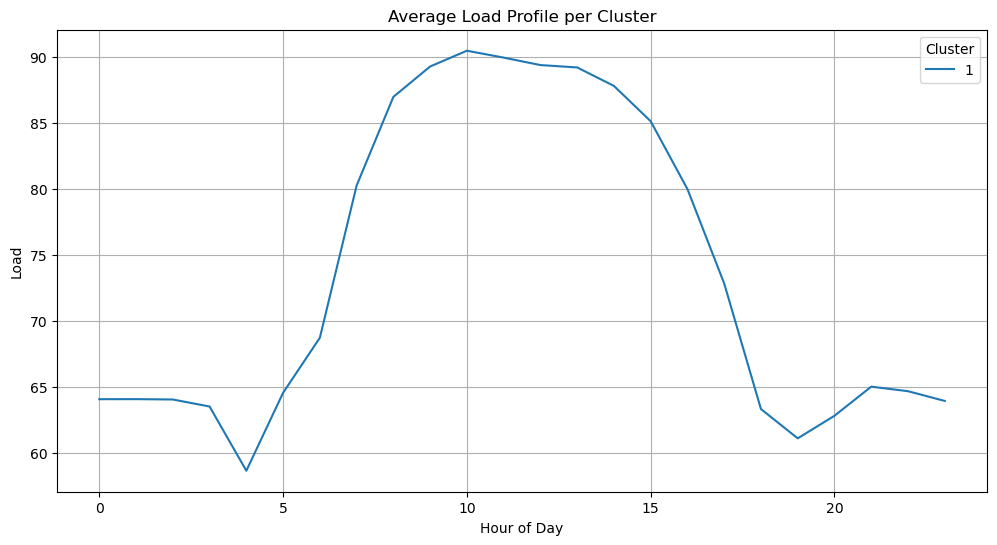

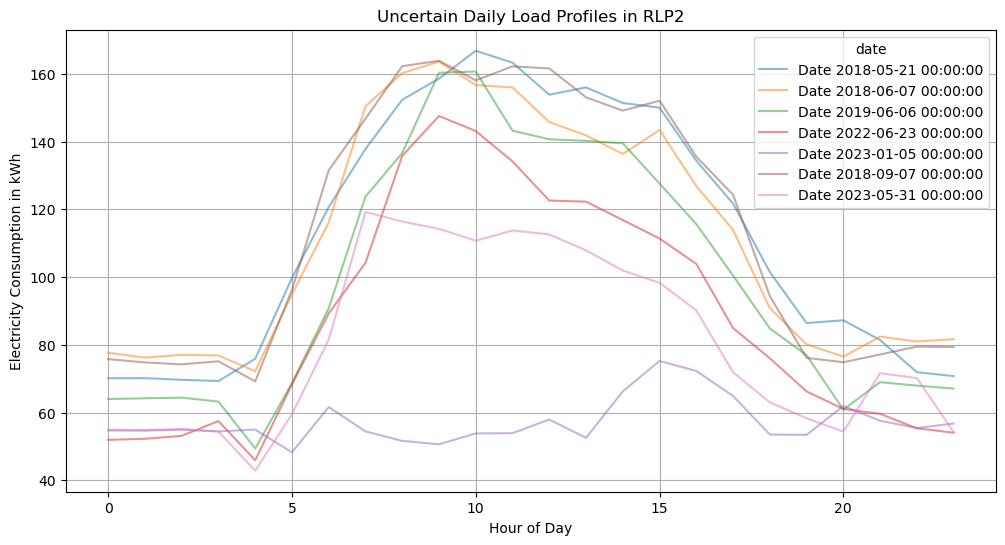

Peak and Minimum Load Profiles:
         Peak_Load  Peak_Hour   Min_Load  Min_Hour
Cluster                                           
1        90.474171         10  58.685275         4
Confidence Intervals for Average Load Profile:
    Cluster  Hour       mean   CI_Lower   CI_Upper
0         1     0  64.099325  63.559937  64.638713
1         1     1  64.102809  63.561698  64.643920
2         1     2  64.076619  63.539245  64.613993
3         1     3  63.544513  62.983580  64.105445
4         1     4  58.685275  58.017954  59.352596
5         1     5  64.583427  63.598785  65.568070
6         1     6  68.750518  67.380625  70.120411
7         1     7  80.266271  78.222638  82.309905
8         1     8  86.982590  84.644641  89.320539
9         1     9  89.280425  86.713706  91.847145
10        1    10  90.474171  87.845852  93.102490
11        1    11  89.952587  87.371560  92.533615
12        1    12  89.388279  86.850679  91.925879
13        1    13  89.208670  86.676291  91.741048
14 

In [39]:
stats, ci_table, u_points = analyze_clusters(df1)
df['year'] = pd.to_datetime(df['Date']).dt.year

In [7]:
u_points[['Date','prob_1','prob_2']].value_counts()

Date        prob_1  prob_2
2018-05-21  0.551   0.449     24
2018-06-07  0.548   0.452     24
2018-09-07  0.551   0.449     24
2019-06-06  0.545   0.455     24
2022-06-23  0.566   0.434     24
2023-01-05  0.525   0.475     24
2023-05-31  0.515   0.485     24
Name: count, dtype: int64

In [8]:
ci_table['CI_diff'] = ci_table['CI_Upper']-ci_table['CI_Lower']

In [9]:
ci_table[ci_table['Cluster']==1]

,Cluster,Hour,mean,std,count,CI_Lower,CI_Upper,CI_diff
0,1,0,64.099325,7.846763,813,63.559937,64.638713,1.078776
1,1,1,64.102809,7.871832,813,63.561698,64.643920,1.082223
2,1,2,64.076619,7.817459,813,63.539245,64.613993,1.074747
3,1,3,63.544513,8.160185,813,62.983580,64.105445,1.121865
4,1,4,58.685275,9.707872,813,58.017954,59.352596,1.334642
5,1,5,64.583427,14.324112,813,63.598785,65.568070,1.969285
6,1,6,68.750518,19.928552,813,67.380625,70.120411,2.739785
7,1,7,80.266271,29.729816,813,78.222638,82.309905,4.087267
8,1,8,86.982590,34.011380,813,84.644641,89.320539,4.675898
9,1,9,89.280425,37.339428,813,86.713706,91.847145,5.133440


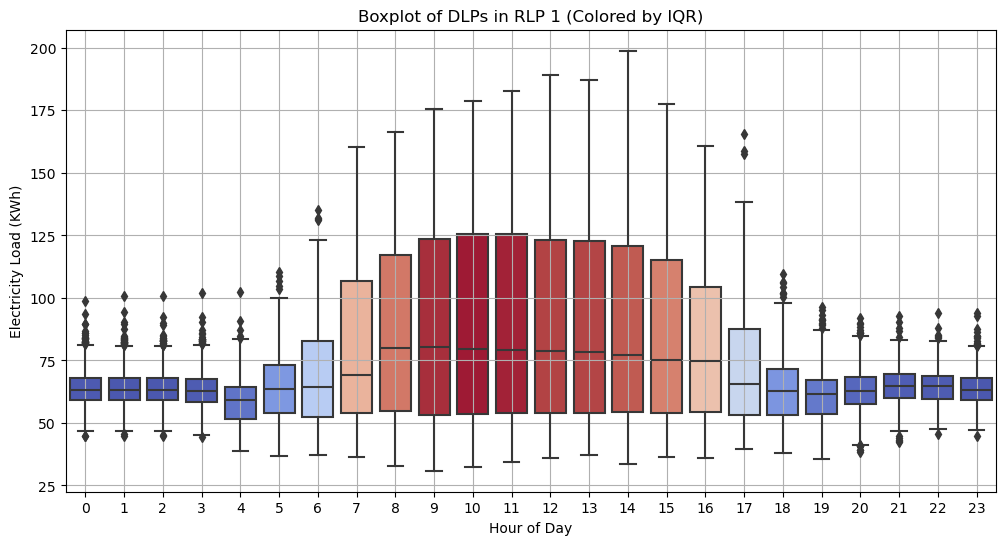

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Step 1: Select only hourly columns
time_columns = [col for col in df.columns if ':' in col]

# Step 2: Melt the dataframe
df_melted = df1.melt(id_vars=['Date', 'DayOfWeek', 'hour', 'season', 'weekday', 'term_time', 'term_week', 'IsHoliday', 'Cluster', 'prob_1', 'prob_2'],
                    value_vars=time_columns,
                    var_name='Time', value_name='Load')

# Step 3: Convert 'Time' to numerical Hour
df_melted['Hour'] = pd.to_datetime(df_melted['Time'], format='%H:%M:%S').dt.hour

# Step 4: Calculate IQR for each hour
iqr_values = df_melted.groupby('Hour')['Load'].agg(lambda x: np.percentile(x, 75) - np.percentile(x, 25))

# Step 5: Normalize IQR values for color mapping
iqr_scaled = (iqr_values - iqr_values.min()) / (iqr_values.max() - iqr_values.min())

# Step 6: Create a color mapping (higher IQR → darker color, lower IQR → lighter color)
color_palette = sns.color_palette("coolwarm", as_cmap=True)

# Step 7: Plot the boxplot
plt.figure(figsize=(12, 6))
ax = sns.boxplot(x='Hour', y='Load', data=df_melted, palette=[color_palette(iqr_scaled[h]) for h in df_melted['Hour'].unique()])

# Step 8: Add title and labels
plt.title('Boxplot of DLPs in RLP 1 (Colored by IQR)')
plt.xlabel('Hour of Day')
plt.ylabel('Electricity Load (KWh)')
plt.grid(True)

# Step 9: Show the plot
plt.show()


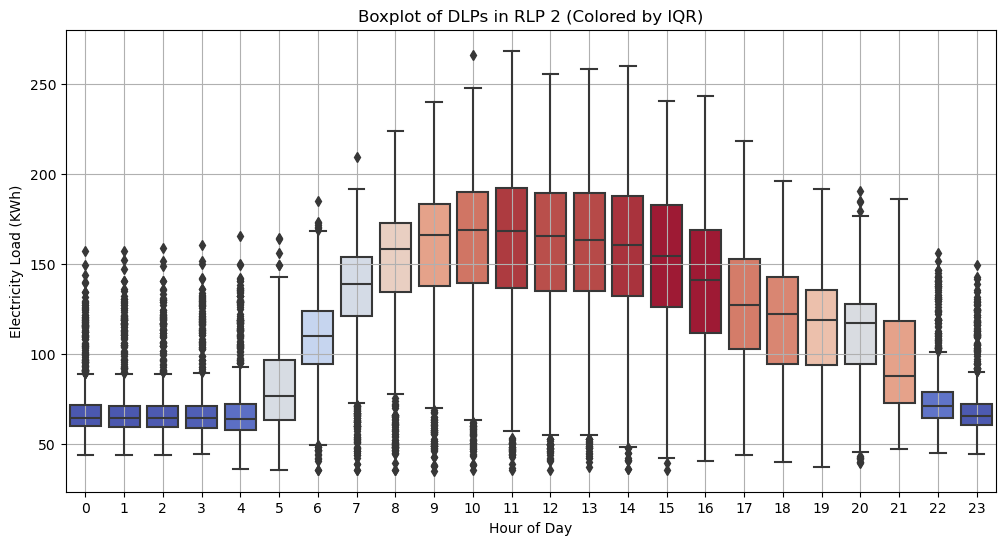

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Step 1: Select only hourly columns
time_columns = [col for col in df.columns if ':' in col]

# Step 2: Melt the dataframe
df_melted = df2.melt(id_vars=['Date', 'DayOfWeek', 'hour', 'season', 'weekday', 'term_time', 'term_week', 'IsHoliday', 'Cluster', 'prob_1', 'prob_2'],
                    value_vars=time_columns,
                    var_name='Time', value_name='Load')

# Step 3: Convert 'Time' to numerical Hour
df_melted['Hour'] = pd.to_datetime(df_melted['Time'], format='%H:%M:%S').dt.hour

# Step 4: Calculate IQR for each hour
iqr_values = df_melted.groupby('Hour')['Load'].agg(lambda x: np.percentile(x, 75) - np.percentile(x, 25))

# Step 5: Normalize IQR values for color mapping
iqr_scaled = (iqr_values - iqr_values.min()) / (iqr_values.max() - iqr_values.min())

# Step 6: Create a color mapping (higher IQR → darker color, lower IQR → lighter color)
color_palette = sns.color_palette("coolwarm", as_cmap=True)

# Step 7: Plot the boxplot
plt.figure(figsize=(12, 6))
ax = sns.boxplot(x='Hour', y='Load', data=df_melted, palette=[color_palette(iqr_scaled[h]) for h in df_melted['Hour'].unique()])

# Step 8: Add title and labels
plt.title('Boxplot of DLPs in RLP 2 (Colored by IQR)')
plt.xlabel('Hour of Day')
plt.ylabel('Electricity Load (KWh)')
plt.grid(True)

# Step 9: Show the plot
plt.show()



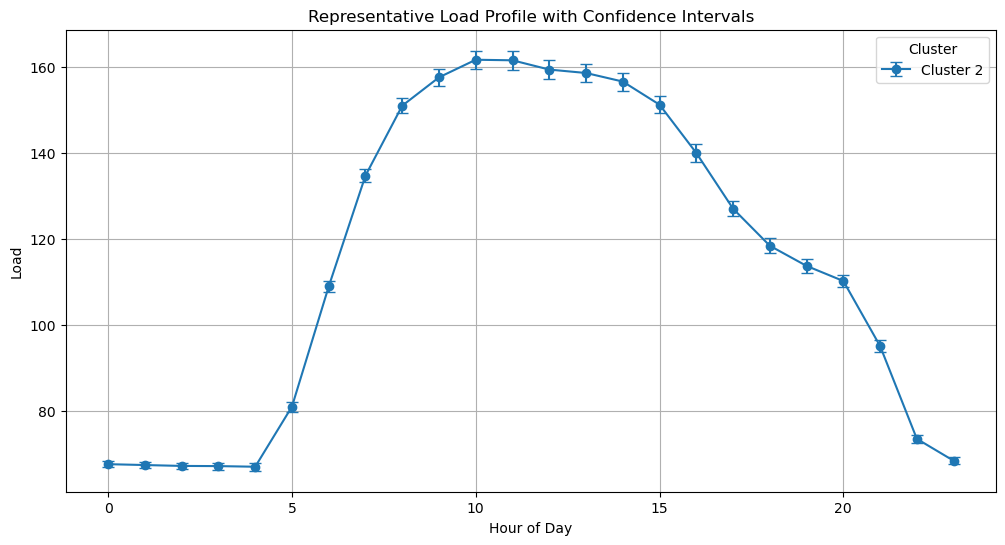

In [53]:
def plot_rlp_with_ci(ci_table):
    plt.figure(figsize=(12, 6))
    
    for cluster in ci_table['Cluster'].unique():
        subset = ci_table[ci_table['Cluster'] == cluster]
        
        # Plot mean values with error bars
        plt.errorbar(
            subset['Hour'], subset['mean'], 
            yerr=[subset['mean'] - subset['CI_Lower'], subset['CI_Upper'] - subset['mean']], 
            fmt='-o', capsize=4, label=f'Cluster {cluster}'
        )
    
    plt.title('Representative Load Profile with Confidence Intervals')
    plt.xlabel('Hour of Day')
    plt.ylabel('Load')
    plt.legend(title='Cluster')
    plt.grid()
    plt.show()

    
plot_rlp_with_ci(ci_table)

In [54]:
stats

,Peak_Load,Peak_Hour,Min_Load,Min_Hour
Cluster,,,,
2,161.582232,10,67.062354,4


In [55]:
ci_table[ci_table['Cluster']==2]['std'].mean()

28.061919772663163

In [56]:
from scipy.spatial.distance import euclidean
from fastdtw import fastdtw
import numpy as np

def compute_distance_between_clusters(df, cluster1, cluster2, method='euclidean'):
    # Convert Date column to datetime
    df['Date'] = pd.to_datetime(df['Date'], format='mixed')
    
    # Identify hour columns
    hour_columns = df.columns[1:25]
    
    # Melt the DataFrame
    melted_df = df.melt(id_vars=['Date', 'Cluster', 'prob_1', 'prob_2'], value_vars=hour_columns, 
                         var_name='Hour', value_name='Load')
    
    # Convert Hour to int
    melted_df['Hour'] = melted_df['Hour'].str[:2].astype(int)
    
    # Compute average load profiles for both clusters
    avg_load_profile = melted_df.groupby(['Cluster', 'Hour'])['Load'].mean().reset_index()
    
    # Extract load profiles for the specified clusters
    profile1 = avg_load_profile[avg_load_profile['Cluster'] == cluster1]['Load'].values
    profile2 = avg_load_profile[avg_load_profile['Cluster'] == cluster2]['Load'].values
    
    # Convert profiles to 1D NumPy arrays
    profile1 = np.asarray(profile1, dtype=np.float64).flatten()
    profile2 = np.asarray(profile2, dtype=np.float64).flatten()
    
    # Ensure both profiles have the same length
    if len(profile1) != len(profile2):
        raise ValueError("Profiles must have the same number of hourly values")
    
    # Compute distance based on selected method
    if method == 'euclidean':
        distance = euclidean(profile1, profile2)
    elif method == 'dtw':
        distance, _ = fastdtw(profile1, profile2, dist=dtw)
    else:
        raise ValueError("Unsupported distance method. Choose 'euclidean' or 'dtw'.")
    
    return distance


In [57]:
distance_euclidean = compute_distance_between_clusters(df,1,2, method='euclidean')
print(f"Euclidean Distance between 1 and 2: {distance_euclidean}")


Euclidean Distance between 1 and 2: 241.23193025396802


In [58]:
filtered_df = df[df['prob_1'].between(0.3, 0.7)]
c1_ambig = filtered_df[filtered_df.Cluster==1]
c1_ambig

,Date,00:00:00,01:00:00,02:00:00,03:00:00,04:00:00,05:00:00,06:00:00,07:00:00,08:00:00,...,hour,season,weekday,term_time,term_week,IsHoliday,Cluster,prob_1,prob_2,year
19,2019-09-07,60.174999,59.907498,60.029999,60.394998,49.194999,69.672500,85.549999,107.299997,117.137495,...,0,4,0,1,0,0,1,0.615,0.385,2019
52,2018-05-21,70.144999,70.164999,69.682499,69.327497,75.879999,99.740000,120.662497,137.797497,152.339996,...,0,2,1,0,0,0,1,0.551,0.449,2018
247,2018-06-07,77.649998,76.239998,77.042498,76.860001,72.217499,94.942499,116.144999,150.427498,160.207500,...,0,3,1,0,0,0,1,0.548,0.452,2018
250,2016-05-30,60.659998,61.202498,60.694999,60.532499,44.772499,66.624999,77.162498,94.754999,106.204998,...,0,2,1,0,0,0,1,0.688,0.312,2016
411,2022-04-16,52.559999,52.644999,52.234999,52.284999,52.419999,47.814999,56.762499,56.544998,63.749999,...,0,2,0,1,0,0,1,0.628,0.372,2022
550,2019-06-06,64.002499,64.227497,64.409998,63.257498,49.389999,68.732499,90.794998,123.749996,136.617493,...,0,3,1,0,0,0,1,0.545,0.455,2019
843,2023-08-24,56.754999,57.159998,56.589999,56.147500,60.109998,81.712500,99.199997,120.167498,113.752497,...,0,3,1,0,0,0,1,0.626,0.374,2023
959,2022-06-23,51.959998,52.269999,53.145000,57.502499,45.940000,68.357498,89.292498,104.219997,135.795002,...,0,3,1,0,0,0,1,0.566,0.434,2022
988,2023-04-07,52.402499,52.659999,56.699999,55.367498,43.402498,68.030000,87.582499,106.059999,112.052496,...,0,2,1,1,1,1,1,0.665,0.335,2023
1061,2023-01-05,54.724998,54.694999,54.952498,54.457500,54.972499,48.272500,61.657498,54.457499,51.644999,...,0,1,1,1,1,1,1,0.525,0.475,2023


In [59]:
c2_ambig = filtered_df[filtered_df.Cluster==2]
c2_ambig

,Date,00:00:00,01:00:00,02:00:00,03:00:00,04:00:00,05:00:00,06:00:00,07:00:00,08:00:00,...,hour,season,weekday,term_time,term_week,IsHoliday,Cluster,prob_1,prob_2,year
157,2019-10-06,60.604999,61.382499,60.844999,60.864999,47.132500,60.284999,98.222498,112.947496,119.122498,...,0,4,0,1,0,0,2,0.420,0.580,2019
418,2016-08-31,65.712498,64.472499,66.004998,67.792498,66.134998,89.502499,92.424997,126.499998,145.492496,...,0,3,1,0,0,0,2,0.340,0.660,2016
797,2018-06-20,76.072498,76.952499,77.827499,77.037498,66.372498,94.457497,117.024998,135.007498,154.252499,...,0,3,1,0,0,0,2,0.475,0.525,2018
1107,2017-10-08,65.122499,63.512498,61.482498,61.474998,62.397498,79.182497,93.042496,118.562498,122.032497,...,0,4,0,1,0,0,2,0.319,0.681,2017
1125,2023-06-17,53.254999,53.142498,53.394999,52.712499,38.477499,44.219999,52.282499,51.419999,50.530000,...,0,3,0,0,0,0,2,0.348,0.652,2023
1163,2013-11-06,59.559999,60.564999,59.597499,59.934999,47.057498,69.344996,86.732498,108.814999,125.057497,...,0,4,1,1,1,1,2,0.363,0.637,2013
1275,2015-03-14,70.504999,70.362497,71.059999,71.029997,70.684999,71.487499,67.437498,72.789997,92.044998,...,0,2,0,1,0,0,2,0.441,0.559,2015
1283,2019-01-19,75.952497,78.362499,76.474997,72.207499,71.879997,71.034998,72.605000,82.262499,112.442499,...,0,1,0,1,0,0,2,0.407,0.593,2019
1586,2018-08-30,71.787498,70.615000,69.742498,71.337498,80.167498,101.774998,111.904999,141.934998,142.097496,...,0,3,1,0,0,0,2,0.433,0.567,2018
1891,2022-08-29,47.634998,47.622499,47.574999,47.624999,47.414999,71.109998,90.272497,104.169998,113.907499,...,0,3,1,0,0,0,2,0.493,0.507,2022


In [60]:
df[df.Cluster==1]['season'].value_counts()
# 1 is winter
# 2 is spring
# 3 is summer
# 4 is autumn

season
3    305
2    198
4    164
1    146
Name: count, dtype: int64

In [61]:
df[df.Cluster==2]['season'].value_counts()

season
1    383
2    379
4    361
3    231
Name: count, dtype: int64

In [62]:
df[df.Cluster==2][['year','season']].value_counts()

year  season
2022  1         52
      4         52
2013  2         50
2022  2         50
2013  1         47
2023  2         46
2015  1         46
2013  4         46
2014  2         45
2018  1         45
2019  4         45
2023  3         44
2018  4         43
2016  2         42
      4         41
2014  1         40
2019  1         40
2017  1         40
2018  2         40
2017  4         40
2023  4         39
2015  2         38
2022  3         38
2023  1         37
2016  1         36
2014  4         36
2017  2         35
2019  2         33
2018  3         31
2019  3         31
2013  3         25
2015  4         19
2014  3         19
2017  3         19
2016  3         14
2015  3         10
Name: count, dtype: int64

In [63]:
df[df.Cluster==2][['year','season']].value_counts()

year  season
2022  1         52
      4         52
2013  2         50
2022  2         50
2013  1         47
2023  2         46
2015  1         46
2013  4         46
2014  2         45
2018  1         45
2019  4         45
2023  3         44
2018  4         43
2016  2         42
      4         41
2014  1         40
2019  1         40
2017  1         40
2018  2         40
2017  4         40
2023  4         39
2015  2         38
2022  3         38
2023  1         37
2016  1         36
2014  4         36
2017  2         35
2019  2         33
2018  3         31
2019  3         31
2013  3         25
2015  4         19
2014  3         19
2017  3         19
2016  3         14
2015  3         10
Name: count, dtype: int64

In [64]:
df

,Date,00:00:00,01:00:00,02:00:00,03:00:00,04:00:00,05:00:00,06:00:00,07:00:00,08:00:00,...,hour,season,weekday,term_time,term_week,IsHoliday,Cluster,prob_1,prob_2,year
0,2015-08-01,61.114998,60.759999,60.639999,61.317498,60.762499,59.717499,100.874998,162.507496,172.074997,...,0,3,0,0,0,0,2,0.000,1.000,2015
1,2014-06-17,61.697499,61.397499,60.902498,52.009998,46.579999,72.524999,86.179996,130.609999,137.590000,...,0,3,1,0,0,0,1,0.999,0.001,2014
2,2015-11-15,64.274999,63.834999,64.202498,64.959999,65.367498,64.872499,66.512499,62.122499,49.192499,...,0,4,0,1,0,0,1,1.000,0.000,2015
3,2023-01-10,63.809999,63.714999,56.770000,56.870000,56.499998,58.497499,55.737498,50.922500,55.437498,...,0,1,1,1,1,1,2,0.000,1.000,2023
4,2017-04-30,67.897499,69.744997,68.412498,68.512497,67.789999,48.657498,50.314999,50.619998,49.702498,...,0,2,0,1,0,0,1,1.000,0.000,2017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2162,2019-08-29,61.487497,63.337500,63.817500,59.642499,58.882499,73.832498,101.114998,119.369995,129.809994,...,0,3,1,0,0,0,2,0.053,0.947,2019
2163,2018-02-19,66.714998,67.072498,67.102499,66.812498,66.542500,105.834997,126.187494,147.117500,168.512501,...,0,1,1,1,1,1,2,0.000,1.000,2018
2164,2018-10-06,75.087498,74.109997,74.159998,72.820000,55.367498,56.697499,57.847499,59.662499,60.007499,...,0,4,0,1,0,0,1,1.000,0.000,2018
2165,2016-10-17,61.084998,61.284998,61.264997,67.587498,69.105000,104.672497,125.224995,163.239998,167.194996,...,0,4,1,1,1,1,2,0.000,1.000,2016


In [65]:
# Convert the 'Date' column to datetime (if not already done)
df['Date'] = pd.to_datetime(df['Date'])

# Extract only the hour columns (assuming all columns up to 'hour' are load values)
hourly_columns = df.columns[1:25]  # Adjust if more or fewer columns represent hourly data

# Compute the mean load profile for each cluster
rlp_df = df.groupby('Cluster')[hourly_columns].mean()

# Ensure the index represents the clusters
rlp_df.index = rlp_df.index.astype(int)

# Display the resulting RLP DataFrame
(rlp_df)


,00:00:00,01:00:00,02:00:00,03:00:00,04:00:00,05:00:00,06:00:00,07:00:00,08:00:00,09:00:00,...,14:00:00,15:00:00,16:00:00,17:00:00,18:00:00,19:00:00,20:00:00,21:00:00,22:00:00,23:00:00
Cluster,,,,,,,,,,,,,,,,,,,,,
1,64.099325,64.102809,64.076619,63.544513,58.685275,64.583427,68.750518,80.266271,86.982590,89.280425,...,87.810641,85.136862,80.001499,72.856213,63.35221,61.136164,62.844722,65.047880,64.703944,63.968034
2,67.656638,67.455246,67.249175,67.208688,67.062354,81.031316,108.927130,134.680841,150.911016,157.497133,...,156.513879,151.141448,139.925979,126.992098,118.38050,113.697717,110.194333,95.080476,73.533396,68.452159


In [66]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import accuracy_score
from scipy.signal import argrelextrema

def extract_rlp_features(rlp_df):
    features = {}
    time_hours = np.arange(len(rlp_df.columns))  # Assuming hourly data
    
    for cluster in rlp_df.index:
        data = rlp_df.loc[cluster].values
        
        # Max and Min Load
        max_load = np.max(data)
        min_load = np.min(data)
        
        # Time of Max and Min Load
        max_time = time_hours[np.argmax(data)]
        min_time = time_hours[np.argmin(data)]
        
        # Local Minima and Maxima
        local_maxima = argrelextrema(data, np.greater)[0]
        local_minima = argrelextrema(data, np.less)[0]
        
        num_local_max = len(local_maxima)
        num_local_min = len(local_minima)
        
        # Time of Local Minima and Maxima
        local_max_times = list(time_hours[local_maxima])
        local_min_times = list(time_hours[local_minima])
        
        # Rate of Change
        rate_of_change = np.diff(data)
        positive_rate = np.mean(rate_of_change[rate_of_change > 0]) if np.any(rate_of_change > 0) else 0
        negative_rate = np.mean(rate_of_change[rate_of_change < 0]) if np.any(rate_of_change < 0) else 0
        overall_gradient = np.mean(rate_of_change)
        
        # Variability & Distribution Features
        std_dev = np.std(data)
        coef_var = std_dev / np.mean(data) if np.mean(data) != 0 else 0
        skewness = pd.Series(data).skew()
        kurtosis = pd.Series(data).kurtosis()
        
        # Peak Load Characteristics
        peak_to_avg_ratio = max_load / np.mean(data) if np.mean(data) != 0 else 0
        load_factor = np.mean(data) / max_load if max_load != 0 else 0
        
        features[cluster] = {
            "max_load": max_load,
            "min_load": min_load,
            "max_time": max_time,
            "min_time": min_time,
            "num_local_max": num_local_max,
            "num_local_min": num_local_min,
            "local_max_times": local_max_times,
            "local_min_times": local_min_times,
            "positive_rate": positive_rate,
            "negative_rate": negative_rate,
            "overall_gradient": overall_gradient,
            "std_dev": std_dev,
            "coef_var": coef_var,
            "skewness": skewness,
            "kurtosis": kurtosis,
            "peak_to_avg_ratio": peak_to_avg_ratio,
            "load_factor": load_factor
        }
    
    return pd.DataFrame(features).T

# Example usage
rlp_features = extract_rlp_features(rlp_df)
rlp_features


,max_load,min_load,max_time,min_time,num_local_max,num_local_min,local_max_times,local_min_times,positive_rate,negative_rate,overall_gradient,std_dev,coef_var,skewness,kurtosis,peak_to_avg_ratio,load_factor
1,90.474171,58.685275,10,4,3,2,"[1, 10, 21]","[4, 19]",3.967122,-2.55967,-0.005708,11.566897,0.156817,0.354968,-1.753456,1.226593,0.815267
2,161.582232,67.062354,10,4,1,1,[10],[4],15.753313,-5.513197,0.034588,36.704716,0.31866,-0.127786,-1.6629,1.402811,0.712854
